<a href="https://colab.research.google.com/github/dongocthao261005-web/nhom5_kpdl/blob/main/Tien_xu_ly_du_lieu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nạp dữ liệu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = "/content/drive/MyDrive/DoAn_KPDL/Mall_Customers.csv"
df = pd.read_csv(path)

# in ra 5 dòng đầu tiên
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Phân tích EDA

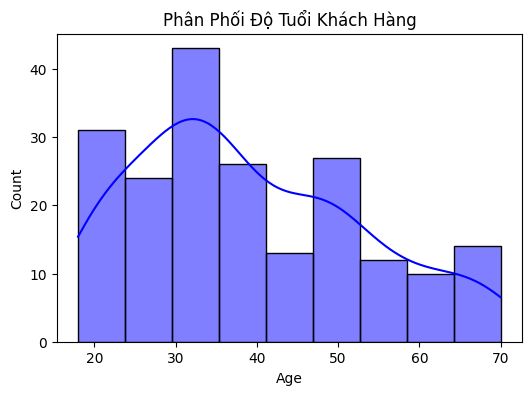

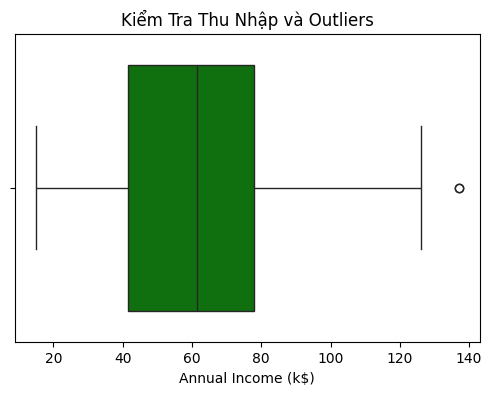

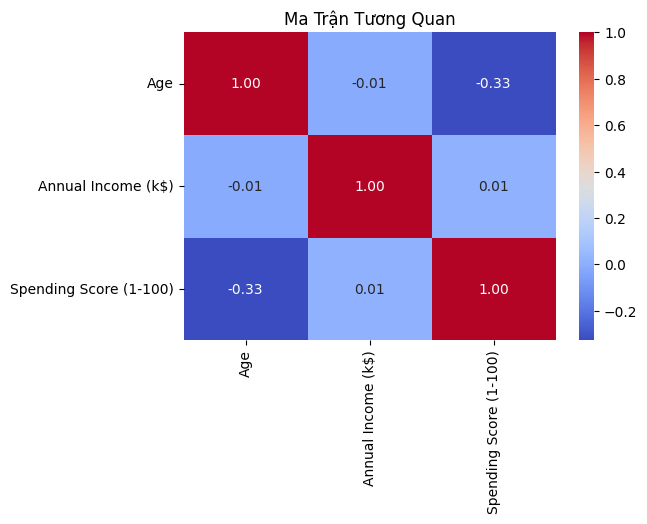

In [ ]:
# Phân phối độ tuổi (Histogram)
plt.figure(figsize=(6, 4))
sns.histplot(df['Age'], kde=True, color='blue')
plt.title('Phân Phối Độ Tuổi Khách Hàng')
plt.show()

# Boxplot kiểm tra Outliers cột Thu nhập
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Annual Income (k$)'], color='green')
plt.title('Kiểm Tra Thu Nhập và Outliers')
plt.show()

# Phân tích tương quan (Correlation Matrix)
plt.figure(figsize=(6, 4))
# Lấy các cột số để tính tương quan
numeric_df = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma Trận Tương Quan')
plt.show()

# Chuẩn hóa dữ liệu

In [ ]:
from sklearn.preprocessing import StandardScaler

# Chỉ lấy những khách hàng có thu nhập <= 130k
df_clean = df[df['Annual Income (k$)'] <= 130].copy()

# Chọn 3 cột chính cần dùng để chạy thuật toán
X = df_clean[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Chuẩn hóa dữ liệu về cùng một thang đo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# In 5 dòng đầu tiên
print(X_scaled[:5])

[[-1.42541358 -1.77917141 -0.43598941]
 [-1.2823665  -1.77917141  1.19941337]
 [-1.35389004 -1.73944701 -1.72094874]
 [-1.13931942 -1.73944701  1.04366072]
 [-0.5671311  -1.69972262 -0.39705125]]


# Chạy K-Means và tìm số cụm tối ưu

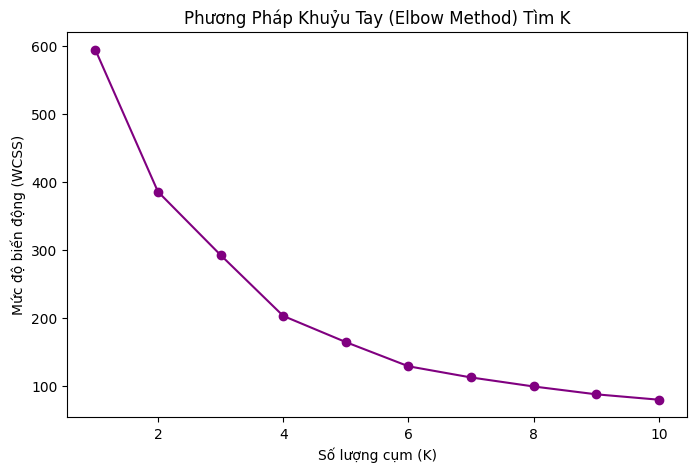

In [ ]:
from sklearn.cluster import KMeans

wcss = []
# Chia từ 1 đến 10 cụm
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Vẽ đồ thị
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='purple')
plt.title('Phương Pháp Khuỷu Tay (Elbow Method) Tìm K')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Mức độ biến động (WCSS)')
plt.show()

# Gán nhãn cụm và xuất

In [ ]:
# Phân nhóm với K=5
kmeans_final = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df_clean['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Xuất file
output_path = "/content/drive/MyDrive/DoAn_KPDL/Cleaned_Labeled_Data.csv"
df_clean.to_csv(output_path, index=False)
print("Xong! Đã xuất file thành công vào Drive!")

Xong! Đã xuất file thành công vào Drive!


# Chạy DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

# Khởi chạy DBSCAN (eps: Bán kính, min_samples: Số điểm tối thiểu)
dbscan = DBSCAN(eps=0.5, min_samples=5)

# Gắn nhãn cụm vào lại dataframe gốc
df_clean['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# Kiểm tra xem có bao nhiêu cụm và bao nhiêu điểm Nhiễu (Noise)
print("Thống kê số lượng khách hàng theo DBSCAN (Nhãn -1 là Nhiễu):")
print(df_clean['DBSCAN_Cluster'].value_counts())

Thống kê số lượng khách hàng theo DBSCAN (Nhãn -1 là Nhiễu):
DBSCAN_Cluster
-1    64
 1    51
 3    32
 2    27
 0    17
 4     7
Name: count, dtype: int64


# Biểu đồ DBSCAN


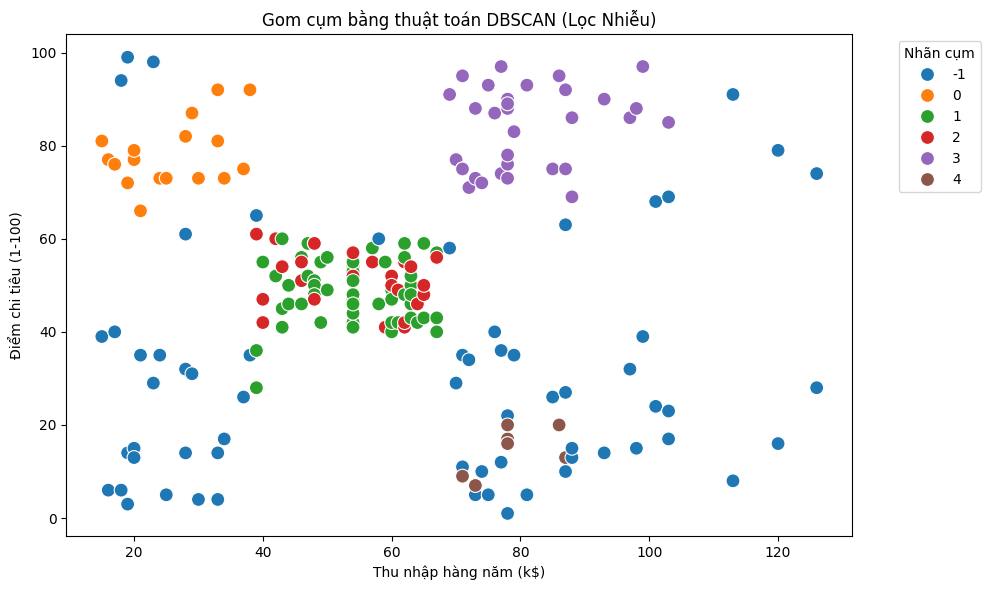

In [ ]:
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ phân tán
sns.scatterplot(data=df_clean,
                x='Annual Income (k$)',
                y='Spending Score (1-100)',
                hue='DBSCAN_Cluster',
                palette='tab10',
                s=100)

plt.title('Gom cụm bằng thuật toán DBSCAN (Lọc Nhiễu)')
plt.xlabel('Thu nhập hàng năm (k$)')
plt.ylabel('Điểm chi tiêu (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Nhãn cụm')
plt.tight_layout()
plt.show()